# Baseline Naive Bayes

## import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB ,MultinomialNB,BernoulliNB,ComplementNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score
from sklearn.metrics import ConfusionMatrixDisplay

In [7]:
df = pd.read_csv('../01_data/spam_clean.csv',encoding="utf-8")
df

,target,transformed_text
0,0,go jurong point crazi avail bugi n great world...
1,0,ok lar joke wif u oni
2,1,free entri 2 wkli comp win fa cup final tkt 21...
3,0,u dun say earli hor u c alreadi say
4,0,nah think goe usf live around though
...,...,...
5164,1,2nd time tri 2 contact u pound prize 2 claim e...
5165,0,b go esplanad fr home
5166,0,piti mood suggest
5167,0,guy bitch act like interest buy someth els nex...


In [8]:
# fill the missing values 
df['transformed_text'] = df['transformed_text'].fillna('')

## Vectorization
convert text to vector 

In [22]:
df

,target,transformed_text
0,0,go jurong point crazi avail bugi n great world...
1,0,ok lar joke wif u oni
2,1,free entri 2 wkli comp win fa cup final tkt 21...
3,0,u dun say earli hor u c alreadi say
4,0,nah think goe usf live around though
...,...,...
5164,1,2nd time tri 2 contact u pound prize 2 claim e...
5165,0,b go esplanad fr home
5166,0,piti mood suggest
5167,0,guy bitch act like interest buy someth els nex...


In [23]:
cv = CountVectorizer(max_features=3000)
tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df['transformed_text']).toarray()
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5169, 6715))

In [24]:
y = df['target'].to_numpy()
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [25]:
print(X.shape)
print(y.shape)

(5169, 6715)
(5169,)


## train test split 

In [26]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

## Model train and evaultion 

In [ ]:
# Initialize all 4 Naive Bayes variants
models = {
    "GaussianNB": GaussianNB(),
    "MultinomialNB": MultinomialNB(),
    "BernoulliNB": BernoulliNB(),
    "ComplementNB": ComplementNB(),
}

#  Train, Predict, and Evaluate
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)

    results.append({"Model": name, "Accuracy": acc, "Precision": prec})


results_df = pd.DataFrame(results).sort_values(by="Precision", ascending=False)
print(results_df.to_string(index=False))

        Model  Accuracy  Precision
MultinomialNB  0.959381   1.000000
  BernoulliNB  0.970019   0.973451
 ComplementNB  0.923598   0.651282
   GaussianNB  0.876209   0.523148


## Confusion Matrix Display

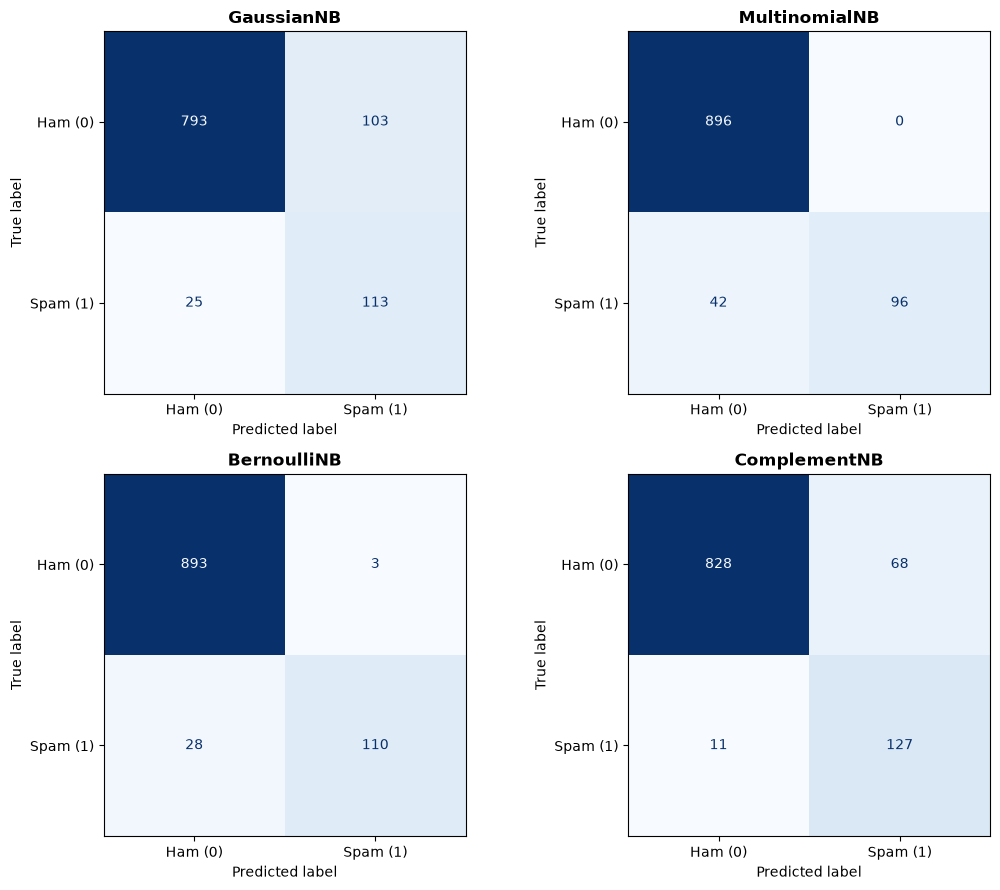

        Model  Accuracy  Precision  False Positives  False Negatives
MultinomialNB    0.9594     1.0000                0               42
  BernoulliNB    0.9700     0.9735                3               28
 ComplementNB    0.9236     0.6513               68               11
   GaussianNB    0.8762     0.5231              103               25


In [ ]:
# 1. Initialize all 4 Naive Bayes variants
models = {
    "GaussianNB": GaussianNB(),
    "MultinomialNB": MultinomialNB(),
    "BernoulliNB": BernoulliNB(),
    "ComplementNB": ComplementNB(),
}

# 2. Setup figure for a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
results = []

# 3. Train, Evaluate, and Plot using ConfusionMatrixDisplay
for ax, (name, model) in zip(axes.ravel(), models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)

    results.append(
        {
            "Model": name,
            "Accuracy": round(acc, 4),
            "Precision": round(prec, 4),
            "False Positives": cm[0, 1],
            "False Negatives": cm[1, 0],
        }
    )

    # Scikit-Learn ConfusionMatrixDisplay
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=["Ham (0)", "Spam (1)"]
    )
    disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
    ax.set_title(f"{name}", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

# 4. Display sorted metrics summary
results_df = pd.DataFrame(results).sort_values(
    by=["Precision", "Accuracy"], ascending=False
)
print(results_df.to_string(index=False))